### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


## Explore the Dataset

In [23]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("grades_crpt.csv")

In [25]:
print(df.shape)
df.info()

(86, 9)
<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


We can see that the dataset has 86 total entries and 9 columns.

In [26]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


From the above output, we can see that some assignments have minimum values less than zero, such as:

- A1 -> minimum = -4.5
- A2 -> minimum = -30.6
- A3 -> minimum = -70.1
- A4 -> minimum = -21.6
- A6 -> minimum = -17.0

This could be due to negative marking, or this could be an error in the data.

We can also see that the maximums for the assignments exceed 100 points.

- A1 -> maximum = 174.6
- A2 -> maximum = 148.6, actual max allowed with bonus = 115
- A3 -> maximum = 152.2
- A4 -> maximum = 188.2, actual max allowed with bonus = 105
- A5 -> maximum = 173.9
- A6 -> maximum = 183.6, actual max allowed with bonus = 110
- A7 -> maximum = 150.6

In [27]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


## Check the correlations

Let's check correlation of values with the final exam.

In [28]:
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


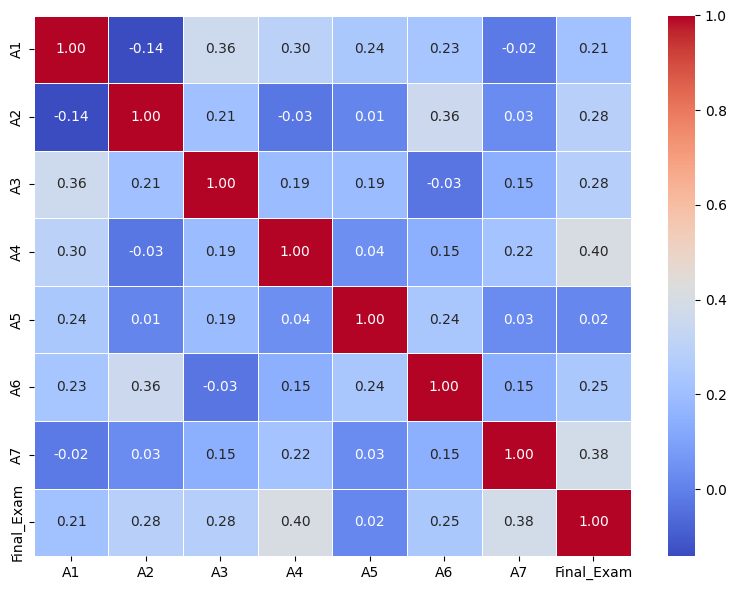

In [29]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

It looks like A4 and A7 have the two highest correlations with Final_Exam (0.40 and 0.38) respectively. This is a positive correlation, which would mean that when the value of one column increases, the value of its related column also increases similarly.

Even though the correlations right now are not very high (greater than 0.5), we can conclude that for each of these assignments, the students who obtained a higher score, also obtained a similar score on the final exam.

## Check for missing values

In [30]:
df.isnull().sum()

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64

From the above output, we can see that the there are some missing values for all Assignments. The final exam and user_id do not have any missing values.

## Handle the missing values

### Using mean

In [31]:
df_mean = df.copy()

for col in numeric_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

df_mean.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.67193,81.096721,30.000000,75.0,90.000000,65.000000,50.600000,68.8,U001
1,100.00000,81.096721,68.174194,92.5,100.000000,100.000000,84.400000,50.3,U002
2,75.00000,69.600000,68.174194,86.2,100.000000,74.437313,78.130263,67.8,U003
3,25.00000,78.600000,40.000000,0.0,50.000000,30.700000,0.000000,0.0,U004
4,0.00000,81.096721,0.000000,0.0,89.645902,74.437313,78.130263,0.0,U005


In [32]:
df_mean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,27.829632,23.992445,35.870997,36.973973,21.433111,27.472004,24.809808,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,89.645902,70.000000,72.500000,45.850000
50%,83.671930,81.096721,68.174194,85.600000,89.822951,74.437313,78.465132,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


### Using median

In [33]:
df_median = df.copy()

for col in numeric_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

df_median.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005


In [34]:
df_median.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,84.962791,84.004651,71.474419,82.873256,91.202326,75.666279,78.347674,55.509302
std,27.889104,24.423614,36.265628,37.008191,21.572171,27.569905,24.817132,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


### Using Removal of Missing Values

In [35]:
df_removed = df.dropna(subset=numeric_cols)
df_removed.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
30,83.3,100.0,60.0,183.1,90.0,70.0,78.8,49.1,U031


In [36]:
df_removed.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,79.930769,80.223077,57.061538,78.838462,79.976923,65.484615,63.800000,52.230769
std,25.731316,18.100145,53.452230,59.102320,27.066712,33.277366,33.562827,23.014719
min,25.000000,57.100000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.000000,64.300000,40.000000,37.500000,80.000000,60.000000,68.800000,38.100000
50%,83.300000,78.600000,63.000000,88.800000,90.000000,72.000000,77.500000,54.400000
75%,91.700000,100.000000,83.000000,95.700000,97.000000,88.000000,81.200000,67.500000
max,129.900000,100.000000,152.200000,183.100000,100.000000,100.000000,112.300000,81.200000


### Evaluating Which Method Is Best For Missing Values

In [37]:
print(df_mean.shape)
print(df_median.shape)
print(df_removed.shape)


(86, 9)
(86, 9)
(13, 9)


We had a total of 86 student rows with their partial assignment data and now we are down to 13 students in `df_removed`. That is major data loss, so handling missing data by dropping those rows does not seem to be an appropriate method. So let's compare mean and median imputation methods now.

In [38]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


In [39]:
df_mean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,27.829632,23.992445,35.870997,36.973973,21.433111,27.472004,24.809808,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,89.645902,70.000000,72.500000,45.850000
50%,83.671930,81.096721,68.174194,85.600000,89.822951,74.437313,78.465132,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


In [40]:
df_median.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,84.962791,84.004651,71.474419,82.873256,91.202326,75.666279,78.347674,55.509302
std,27.889104,24.423614,36.265628,37.008191,21.572171,27.569905,24.817132,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


We can see that filling the missing values with the mean of each assignment has not altered the mean from the original `df` dataframe while the median has changed the mean values for `df_median`. Both have changed the std and interquartile values.

As our dataset contains some negative and positive outliers, as we can see from the minimum and maximum values of each column (and is stated below), it would be better to use the median value to fill in the missing values as median imputation is less sensitive to extreme values while retaining the average, std and interquartile ranges, while the mean imputation may actually cause us to have larger / incorrect values due to the outliers that are considered when calculating its value.

## Check for Outliers

Lets see how many values exceed the total / or is negative (outliers) using frequency histograms. We will use `df_median` from here onwards.

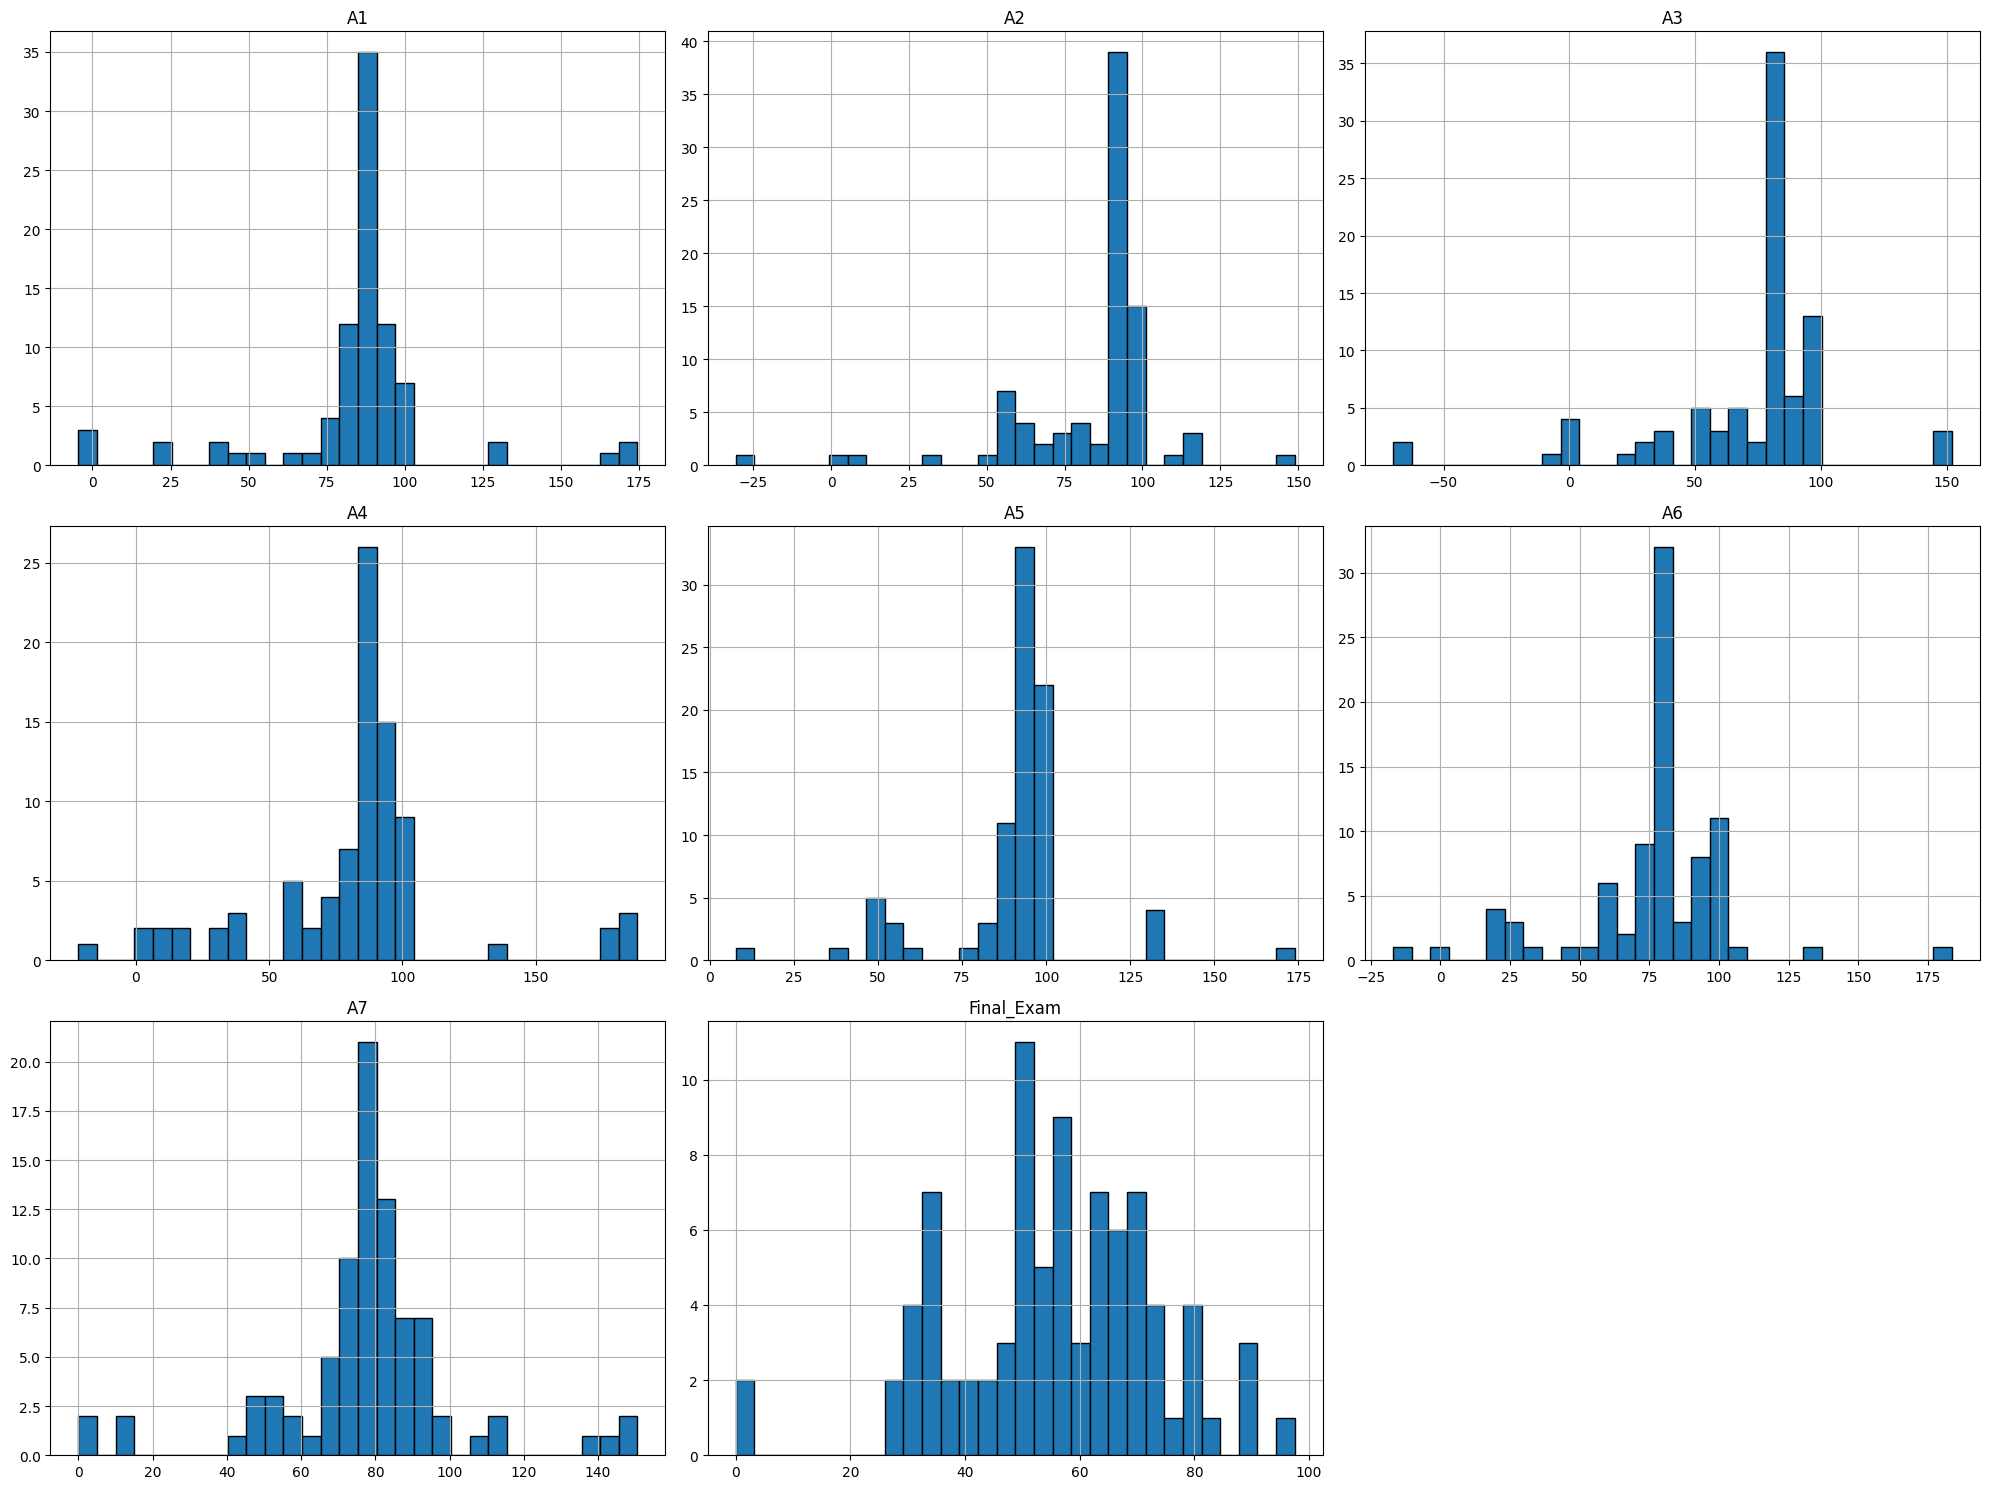

In [65]:
df_median.hist(bins=30, edgecolor='black', figsize=(20, 15))

plt.tight_layout()
plt.show()


In [66]:
print("Number of negative values in each column:")

for col in numeric_cols:
    negative_count = (df_median[col] < 0).sum()
    print(f"{col}: {negative_count}")

Number of negative values in each column:
A1: 1
A2: 1
A3: 4
A4: 1
A5: 0
A6: 1
A7: 0
Final_Exam: 0


Hence, we can see from the graphs and from the above output that there are some negative values (outliers) in the columns for A1, A2, A4 and A6. We could clean these error values up by setting them to zero as a student cannot have negative marks. The minimum they can achieve is 0.

In [67]:
print("Number of values greater than max in each column:")

max_thresholds = {
    'A1': 100, 
    'A2': 115,
    'A3': 100,
    'A4': 105,
    'A5': 100,
    'A6': 110,
    'A7': 100,
    'Final_Exam': 100
}

for col in numeric_cols:
    print(f"{col}: {(df_median[col] > max_thresholds[col]).sum()}")


Number of values greater than max in each column:
A1: 5
A2: 1
A3: 3
A4: 6
A5: 5
A6: 2
A7: 7
Final_Exam: 0


Hence, we can see from the graphs and from the above output that there are some values that are greater than the maximum allowed per assignment (outliers) in the columns for all assignments. We could clean these error values up by setting them to the maximum with bonus marks that is allowed, i.e, 100 + bonus marks (if any).

Let's modify these values as stated above, starting with the negative ones.

In [ ]:
df_clean = df_median.copy()

df_clean[numeric_cols] = df_clean[numeric_cols].apply(lambda col: col.apply(lambda x: 0 if x < 0 else x))
df_clean.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005


Now let's set positive outliers above the threshold to the max value for each assignment.

In [69]:
for col in numeric_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: max_thresholds[col] if x > max_thresholds[col] else x
    )

df_clean.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005


Now let's check observe what `df_clean` looks like.

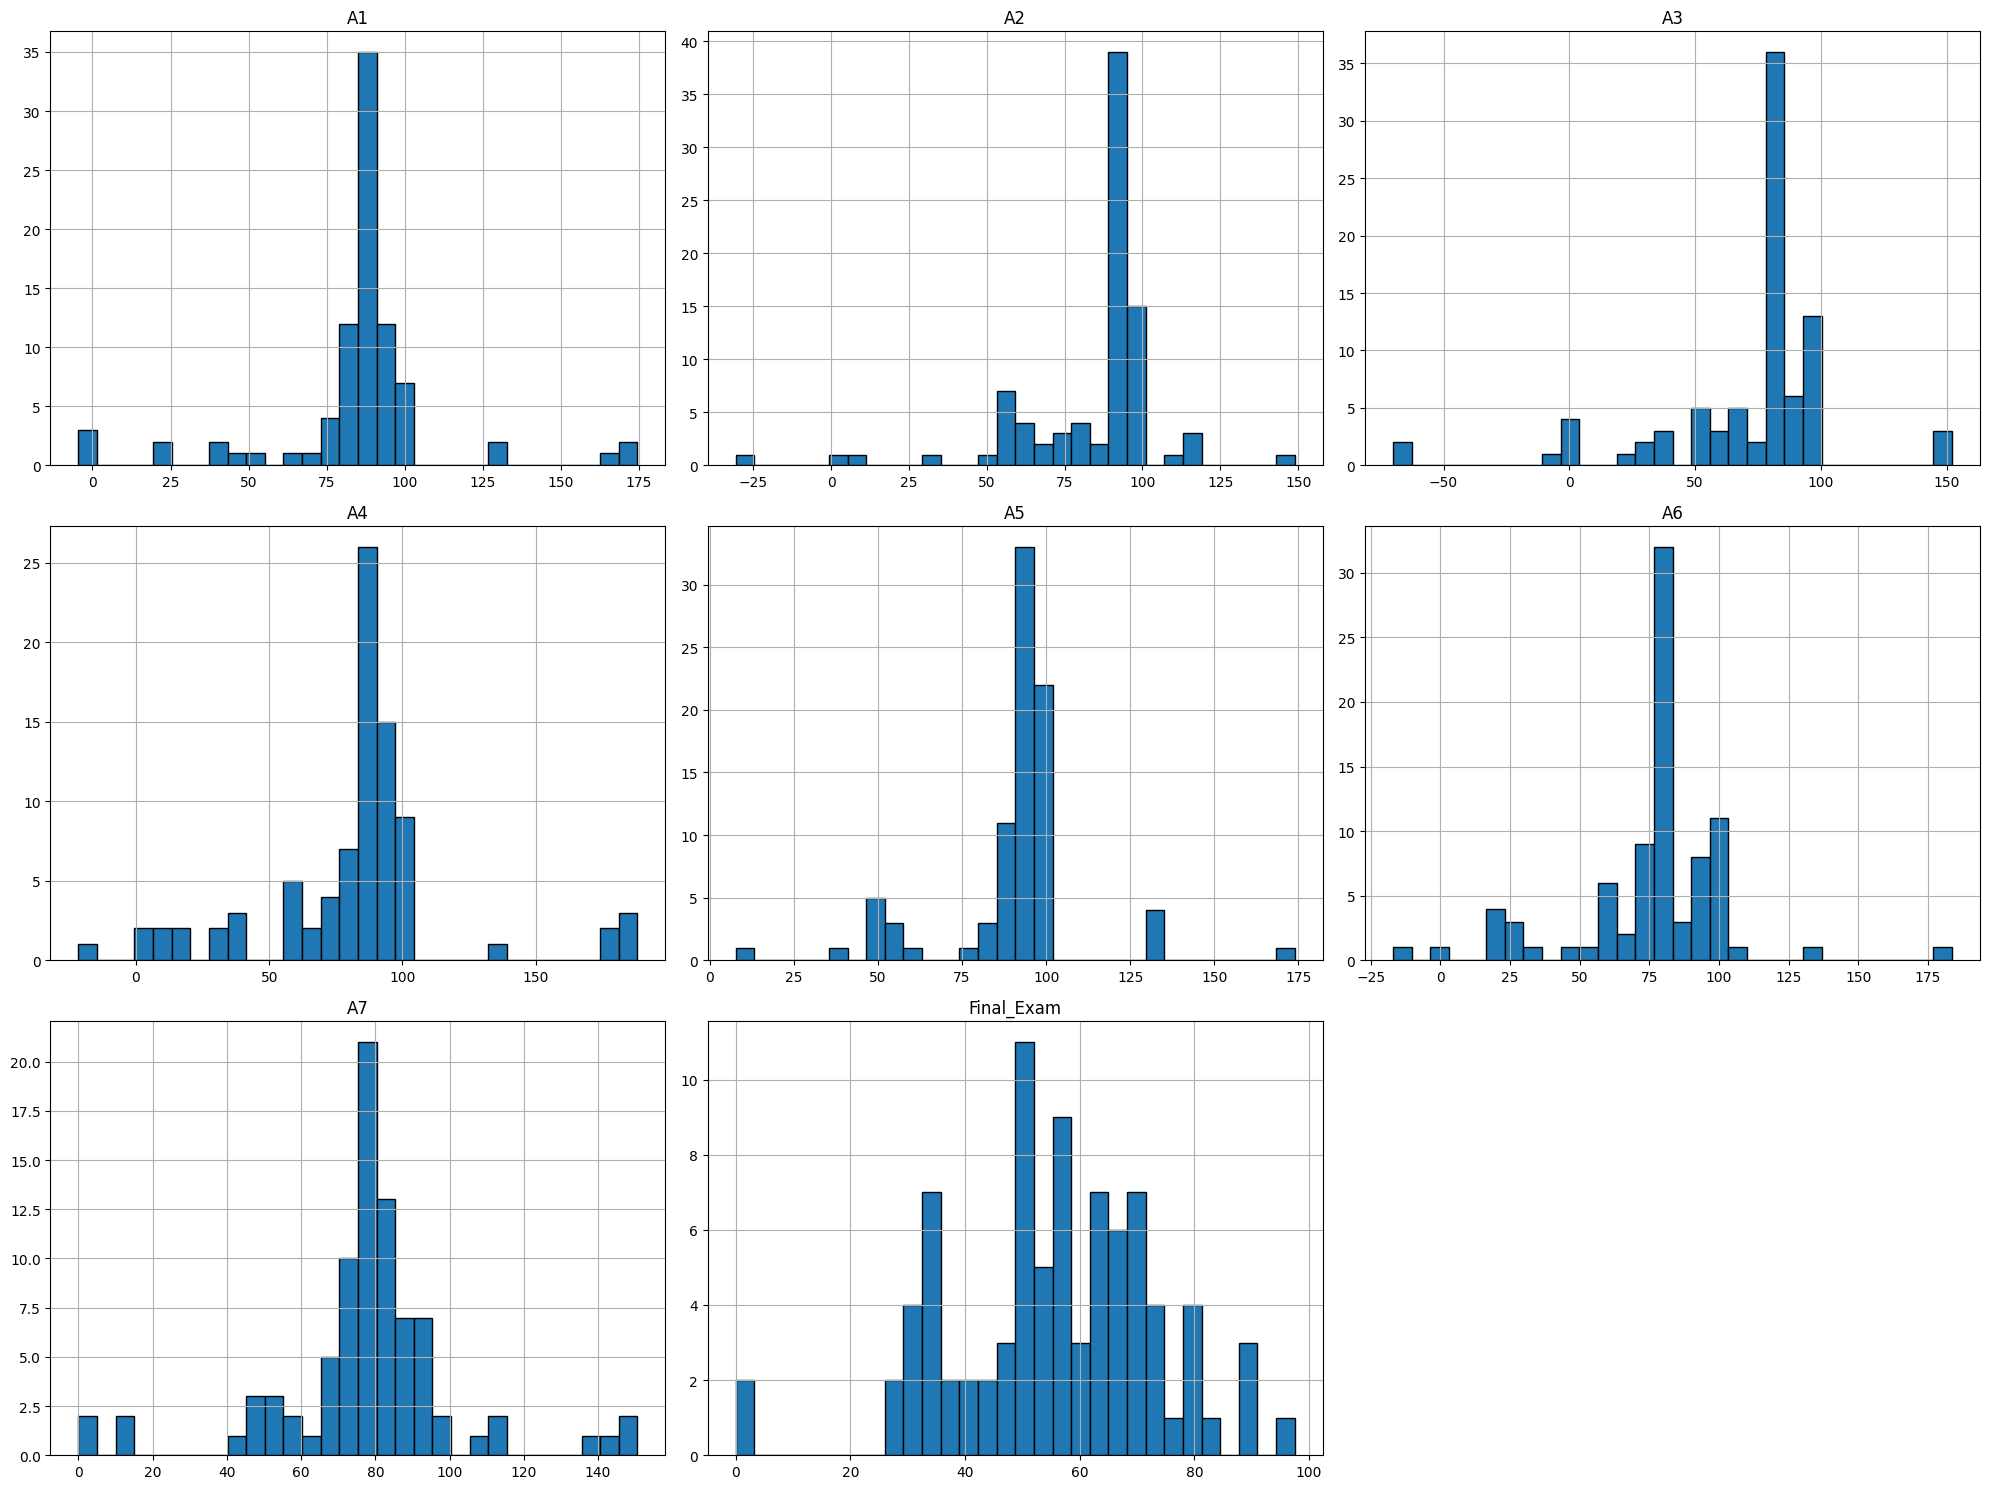

In [70]:
df_median.hist(bins=30, edgecolor='black', figsize=(20, 15))
plt.tight_layout()
plt.show()

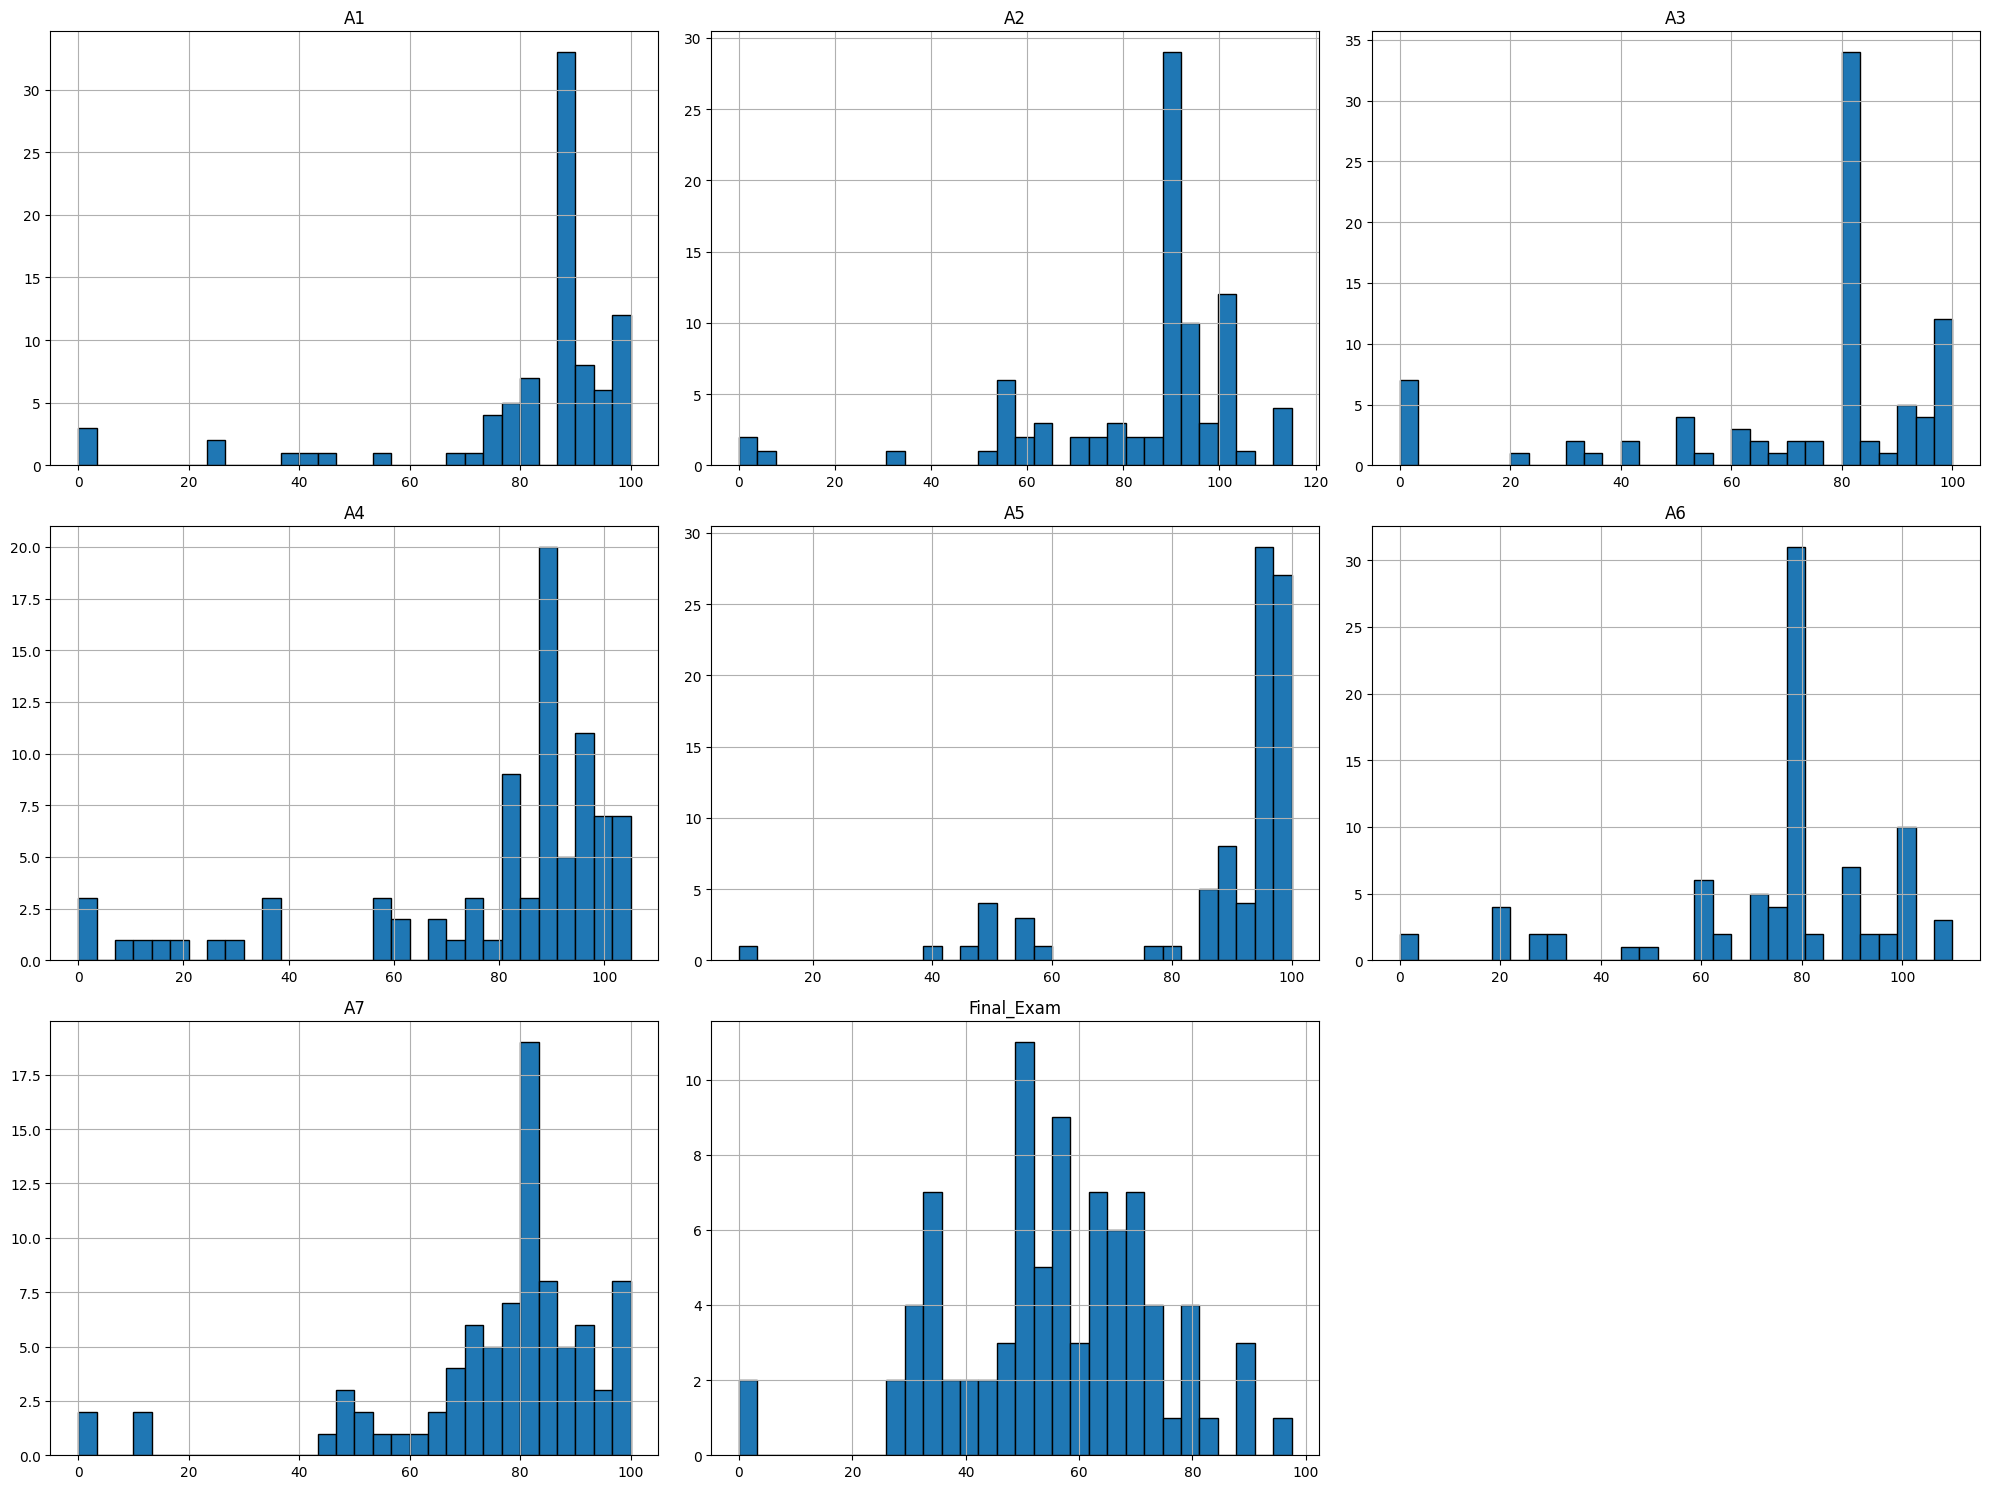

In [71]:
df_clean.hist(bins=30, edgecolor='black', figsize=(20, 15))
plt.tight_layout()
plt.show()

We can see from the histograms that `df_clean` does not have outliers anymore compared to the uncleaned values of `df_median`.

In [72]:
df_median.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,84.962791,84.004651,71.474419,82.873256,91.202326,75.666279,78.347674,55.509302
std,27.889104,24.423614,36.265628,37.008191,21.572171,27.569905,24.817132,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


In [73]:
df_clean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,81.850000,83.966279,71.406977,78.324419,88.847674,74.701163,75.916279,55.509302
std,21.563104,22.062833,27.590867,26.974088,17.461768,23.932761,20.167614,18.176777
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,100.000000,115.000000,100.000000,105.000000,100.000000,110.000000,100.000000,97.500000


We can also see that the `min` and `max` values of `df_clean` are much more aligned with the assignment grading thresholds we defined. Just removing the outliers would not have been as much of a relevant solution as creating thresholds and then capping the values at those thresholds.